In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# 从PDF中提取图片并使用AlexNet提取特征
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import pdf2image
from scipy.spatial.distance import cosine
import os

In [2]:
ep_encoder_features = np.load('/media/ubuntu/sda/Monkey/semantic/direct_train_monkeyF/ep_encoder_features.npy')
image_inf = pd.read_csv("/media/ubuntu/sda/Monkey/data/train_image_MonkeyF.csv")

In [2]:
# page_width, page_height = page_img.size
# print(f"页面尺寸: {page_width} x {page_height}")

# vertical_lines = [20, 1110, 1210, 2300, 2400, 3490]
# horizontal_lines = [115, 1205, 1250, 2340]

# print(f"\n竖线位置 (x坐标): {[f'{x:.1f}' for x in vertical_lines]}")
# print(f"横线位置 (y坐标): {[f'{y:.1f}' for y in horizontal_lines]}")

# # 可视化
# fig, ax = plt.subplots(figsize=(12, 10))
# fig.patch.set_facecolor('black')

# # 显示原图
# ax.imshow(page_img)

# # 绘制竖线（青色）- 共6条竖线
# for x in vertical_lines:
#     ax.axvline(x=x, color='red', linestyle='--', linewidth=1.5, alpha=1)

# # 绘制横线（黄色）- 共4条横线
# for y in horizontal_lines:
#     ax.axhline(y=y, color='red', linestyle='--', linewidth=1.5, alpha=1)

# # 添加边距后的实际裁剪区域
# margin = 10
# crop_left = vertical_lines[0] + margin
# crop_right = vertical_lines[-1] - margin
# crop_top = horizontal_lines[0] + margin
# crop_bottom = horizontal_lines[-1] - margin

# print(f"\n实际裁剪区域:")
# print(f"  左边: {crop_left:.1f}, 右边: {crop_right:.1f}")
# print(f"  上边: {crop_top:.1f}, 下边: {crop_bottom:.1f}")
# print(f"  宽度: {crop_right - crop_left:.1f}, 高度: {crop_bottom - crop_top:.1f}")

# ax.set_xlim(0, page_width)
# ax.set_ylim(page_height, 0)
# ax.axis('off')

# plt.tight_layout()
# plt.show()

# print("\n根据网格线调整 top_offset 参数")

In [3]:
# 正确提取所有图片（使用正确的索引）
import matplotlib.pyplot as plt
from PIL import Image
import pdf2image
import os

pdf_path = '/media/ubuntu/sda/Monkey/semantic/direct_train_monkeyF/full_reconstructions.pdf'

# 竖线：1-2，3-4，5-6 是三列（索引 0-1, 2-3, 4-5）
# 横线：1-2，3-4 是两行（索引 0-1, 2-3）
vertical_lines = [20, 1110, 1210, 2300, 2400, 3490]
horizontal_lines = [115, 1205, 1250, 2340]

print("正在将PDF转换为图像...")
images = pdf2image.convert_from_path(pdf_path)
print(f"共有 {len(images)} 页")

# 存储所有提取的图片
all_extracted_images = []

# 遍历每一页
for page_idx, page_img in enumerate(images):
    page_images = []
    
    for row in range(2):
        for col in range(3):
            # 正确的索引方式
            left = vertical_lines[col * 2]
            right = vertical_lines[col * 2 + 1]
            top = horizontal_lines[row * 2]
            bottom = horizontal_lines[row * 2 + 1]
            
            crop_img = page_img.crop((left, top, right, bottom))
            page_images.append(crop_img)
            
    
    all_extracted_images.append(page_images)
    
    if (page_idx + 1) % 20 == 0:
        print(f"已处理 {page_idx + 1}/{len(images)} 页")
        

print(f"总样本数: {len(all_extracted_images)}")

正在将PDF转换为图像...
共有 100 页
已处理 20/100 页
已处理 40/100 页
已处理 60/100 页
已处理 80/100 页
已处理 100/100 页
总样本数: 100


In [4]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

alexnet = models.alexnet(pretrained=True)
alexnet.eval()
alexnet = alexnet.to(device)

# 移除分类层，保留特征提取部分
class AlexNetFeatureExtractor(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.features = model.features
        self.avgpool = model.avgpool
        self.classifier = model.classifier
        
    def forward(self, x):
        # Conv1-5
        x = self.features(x)
        conv5 = x
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        # FC6-8
        x = self.classifier[1](x)
        fc6 = x
        x = self.classifier[4](x)
        fc7 = x
        x = self.classifier[6](x)
        fc8 = x
        return conv5, fc6, fc7, fc8

extractor = AlexNetFeatureExtractor(alexnet)
extractor.eval()

# 图像预处理
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


def extract_features(img):
    img_tensor = preprocess(img).unsqueeze(0).to(device)
    with torch.no_grad():
        conv5, fc6, fc7, fc8 = extractor(img_tensor)
    return {
        'conv1': None,  # AlexNet的features第一层输出
        'conv2': None,
        'conv3': None,
        'conv4': None,
        'conv5': conv5.squeeze().cpu().numpy(),
        'fc6': fc6.squeeze().cpu().numpy(),
        'fc7': fc7.squeeze().cpu().numpy(),
        'fc8': fc8.squeeze().cpu().numpy()
    }

class AlexNetMultiLayerExtractor(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.features = model.features
        self.avgpool = model.avgpool
        self.classifier = model.classifier
        
    def forward(self, x):
        features = {}
        # Conv1
        x = self.features[0](x)
        features['conv1'] = x
        # Conv2
        x = self.features[3](x)
        features['conv2'] = x
        # Conv3
        x = self.features[6](x)
        features['conv3'] = x
        # Conv4
        x = self.features[8](x)
        features['conv4'] = x
        # Conv5
        x = self.features[10](x)
        features['conv5'] = x
        # Average pool
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        # FC6
        x = self.classifier[1](x)
        features['fc6'] = x
        # FC7
        x = self.classifier[4](x)
        features['fc7'] = x
        # FC8
        x = self.classifier[6](x)
        features['fc8'] = x
        return features

extractor_all = AlexNetMultiLayerExtractor(alexnet)
extractor_all.eval()

def extract_all_features(img):
    img_tensor = preprocess(img).unsqueeze(0).to(device)
    with torch.no_grad():
        features = extractor_all(img_tensor)
    # 将所有特征展平并转为numpy
    for key in features:
        features[key] = features[key].squeeze().cpu().numpy()
    return features



使用设备: cuda


/home/ubuntu/.conda/envs/spike_sorting/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ubuntu/.conda/envs/spike_sorting/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


正在提取AlexNet特征...
已处理 10/100 个样本
已处理 20/100 个样本
已处理 30/100 个样本
已处理 40/100 个样本
已处理 50/100 个样本
已处理 60/100 个样本
已处理 70/100 个样本
已处理 80/100 个样本
已处理 90/100 个样本
已处理 100/100 个样本
特征提取完成！共 100 个样本

计算相似性...

各层的平均相似性:
  conv1: 0.2775 ± 0.1362
  conv2: 0.5194 ± 0.1174
  conv3: 0.5411 ± 0.1158
  conv4: 0.8189 ± 0.0715
  conv5: 0.9581 ± 0.0217
  fc6: 0.9953 ± 0.0054
  fc7: 0.9989 ± 0.0016


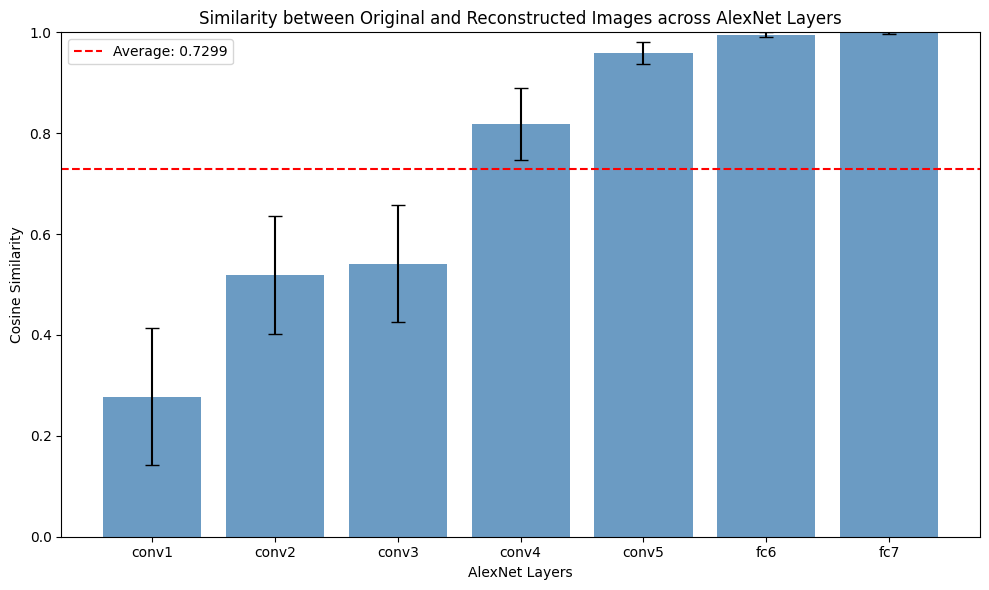


相似性分析完成！


In [6]:
# 使用 all_extracted_images 提取AlexNet特征
print("正在提取AlexNet特征...")
all_features = []

for sample_idx, sample_imgs in enumerate(all_extracted_images):
    sample_features = []
    for img in sample_imgs:
        features = extract_all_features(img)
        sample_features.append(features)
    all_features.append(sample_features)
    if (sample_idx + 1) % 10 == 0:
        print(f"已处理 {sample_idx + 1}/{len(all_extracted_images)} 个样本")

print(f"特征提取完成！共 {len(all_features)} 个样本")

# 计算相似性函数 - 支持多维数组（Conv层是3D，FC层是1D）
def cosine_similarity(vec1, vec2):
    # 展平为1D向量
    vec1 = vec1.reshape(-1)
    vec2 = vec2.reshape(-1)
    return 1 - cosine(vec1, vec2)

# 计算每个样本内部（原始图片与重建图片之间）的相似性
print("\n计算相似性...")
# 不使用FC8，因为它是分类层，输出的是类别概率
layer_names = ['conv1', 'conv2', 'conv3', 'conv4', 'conv5', 'fc6', 'fc7']

similarity_results = {layer: [] for layer in layer_names}

for sample_idx, sample_features in enumerate(all_features):
    original_features = sample_features[0]  # 第一张是原始图片
    
    for recon_idx in range(1, 6):  # 5个重建图片
        recon_features = sample_features[recon_idx]
        for layer in layer_names:
            sim = cosine_similarity(original_features[layer], recon_features[layer])
            similarity_results[layer].append(sim)

# 计算每个层的平均相似性
print("\n各层的平均相似性:")
avg_similarity = {}
for layer in layer_names:
    avg_sim = np.mean(similarity_results[layer])
    std_sim = np.std(similarity_results[layer])
    avg_similarity[layer] = (avg_sim, std_sim)
    print(f"  {layer}: {avg_sim:.4f} ± {std_sim:.4f}")

# 可视化相似性
fig, ax = plt.subplots(figsize=(10, 6))
layers = list(avg_similarity.keys())
means = [avg_similarity[l][0] for l in layers]
stds = [avg_similarity[l][1] for l in layers]

bars = ax.bar(layers, means, yerr=stds, capsize=5, color='steelblue', alpha=0.8)
ax.set_xlabel('AlexNet Layers')
ax.set_ylabel('Cosine Similarity')
ax.set_title('Similarity between Original and Reconstructed Images across AlexNet Layers')
ax.set_ylim(0, 1)
ax.axhline(y=np.mean(means), color='red', linestyle='--', label=f'Average: {np.mean(means):.4f}')
ax.legend()

plt.tight_layout()
#plt.savefig('/media/ubuntu/sda/Monkey/semantic/direct_train_monkeyF/similarity_by_layer.png', dpi=150)
plt.show()

print("\n相似性分析完成！")


Shuffle对比实验
正在计算Shuffle后的相似性...

各层的平均相似性对比:
----------------------------------------------------------------------
Layer    真实配对               Shuffle后           差异         t检验
----------------------------------------------------------------------
conv1    0.2775 ± 0.1362   0.2123 ± 0.1178    +0.0652   p=9.98e-06 ***
conv2    0.5194 ± 0.1174   0.4689 ± 0.1318    +0.0505   p=1.40e-04 ***
conv3    0.5411 ± 0.1158   0.4998 ± 0.1122    +0.0413   p=1.15e-03 **
conv4    0.8189 ± 0.0715   0.7971 ± 0.0692    +0.0218   p=5.36e-03 **
conv5    0.9581 ± 0.0217   0.9533 ± 0.0211    +0.0048   p=4.17e-02 *
fc6      0.9953 ± 0.0054   0.9910 ± 0.0154    +0.0043   p=1.16e-06 ***
fc7      0.9989 ± 0.0016   0.9972 ± 0.0069    +0.0017   p=1.63e-06 ***
----------------------------------------------------------------------

显著性: *** p<0.001, ** p<0.01, * p<0.05, ns 不显著


/tmp/ipykernel_1192579/1900821207.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(layer_names)
/tmp/ipykernel_1192579/1900821207.py:116: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1192579/1900821207.py:116: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1192579/1900821207.py:116: UserWarning: Glyph 37197 (\N{CJK UNIFIED IDEOGRAPH-914D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1192579/1900821207.py:116: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1192579/1900821207.py:116: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_119257

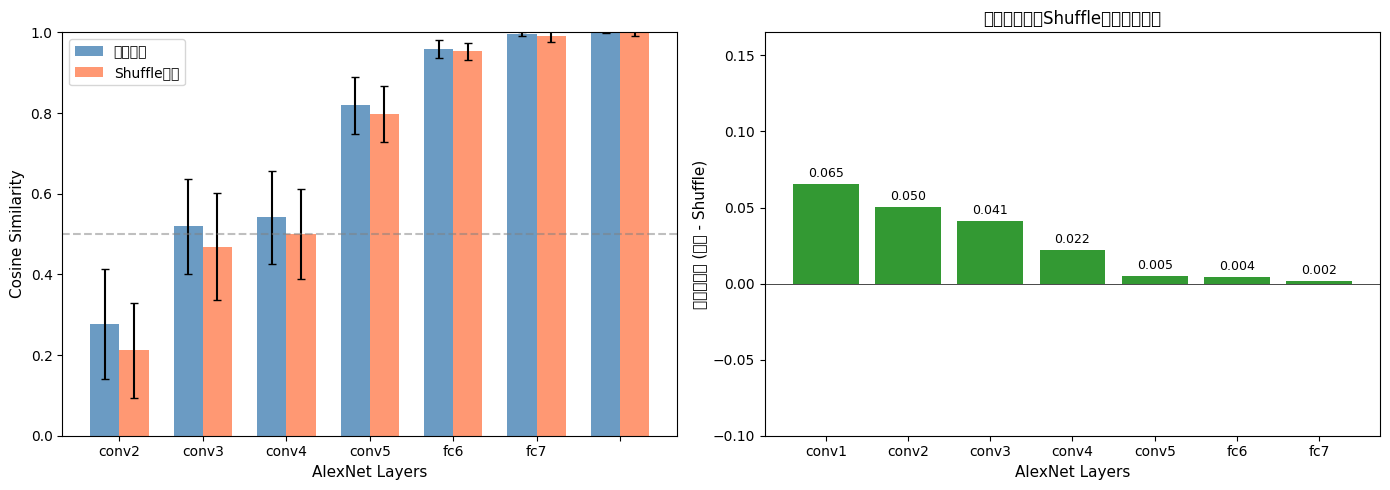


Shuffle对比实验完成！
如果差异显著为正，说明原始图像和其重建图像确实存在真实的语义相似性


In [9]:
# Shuffle对比实验：验证原始图像和重建图像之间是否存在真实相似性
print("\n" + "="*70)
print("Shuffle对比实验")
print("="*70)

# 收集所有原始图片特征和所有重建图片特征
all_original_features = {layer: [] for layer in layer_names}
all_recon_features = {layer: [] for layer in layer_names}

for sample_features in all_features:
    for layer in layer_names:
        all_original_features[layer].append(sample_features[0][layer])  # 原始图片
        # 5个重建图片
        for recon_idx in range(1, 6):
            all_recon_features[layer].append(sample_features[recon_idx][layer])

# 打乱重建图片的顺序，然后重新配对计算相似性
print("正在计算Shuffle后的相似性...")
np.random.seed(42)  # 保证可重复性

shuffle_results = {layer: [] for layer in layer_names}

for layer in layer_names:
    original_arr = np.array([f.reshape(-1) for f in all_original_features[layer]])
    recon_arr = np.array([f.reshape(-1) for f in all_recon_features[layer]])
    
    # 打乱重建图片的索引
    shuffled_indices = np.random.permutation(len(recon_arr))
    recon_shuffled = recon_arr[shuffled_indices]
    
    # 计算打乱后的相似性
    for i in range(len(original_arr)):
        sim = 1 - cosine(original_arr[i], recon_shuffled[i])
        shuffle_results[layer].append(sim)

# 打印对比结果
print("\n各层的平均相似性对比:")
print("-" * 70)
print(f"{'Layer':<8} {'真实配对':<18} {'Shuffle后':<18} {'差异':<10} {'t检验'}")
print("-" * 70)

from scipy import stats

comparison_results = {}
for layer in layer_names:
    real_sims = similarity_results[layer]
    shuffle_sims = shuffle_results[layer]
    
    avg_real = np.mean(real_sims)
    avg_shuffle = np.mean(shuffle_sims)
    diff = avg_real - avg_shuffle
    
    # t检验
    t_stat, p_value = stats.ttest_ind(real_sims, shuffle_sims)
    sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
    
    comparison_results[layer] = {
        'real': avg_real,
        'shuffle': avg_shuffle,
        'diff': diff,
        'p_value': p_value,
        'sig': sig
    }
    
    print(f"{layer:<8} {avg_real:.4f} ± {np.std(real_sims):.4f}   "
          f"{avg_shuffle:.4f} ± {np.std(shuffle_sims):.4f}    {diff:+.4f}   p={p_value:.2e} {sig}")

print("-" * 70)
print("\n显著性: *** p<0.001, ** p<0.01, * p<0.05, ns 不显著")

# 可视化对比
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：柱状图对比
ax1 = axes[0]
x = np.arange(len(layer_names))
width = 0.35

real_means = [comparison_results[l]['real'] for l in layer_names]
real_stds = [np.std(similarity_results[l]) for l in layer_names]
shuffle_means = [comparison_results[l]['shuffle'] for l in layer_names]
shuffle_stds = [np.std(shuffle_results[l]) for l in layer_names]

bars1 = ax1.bar(x - width/2, real_means, width, yerr=real_stds, 
               label='真实配对', color='steelblue', alpha=0.8, capsize=3)
bars2 = ax1.bar(x + width/2, shuffle_means, width, yerr=shuffle_stds, 
               label='Shuffle配对', color='coral', alpha=0.8, capsize=3)

ax1.set_xlabel('AlexNet Layers', fontsize=11)
ax1.set_ylabel('Cosine Similarity', fontsize=11)
ax1.set_xticklabels(layer_names)
ax1.legend()
ax1.set_ylim(0, 1)
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# 右图：差异柱状图
ax2 = axes[1]
diffs = [comparison_results[l]['diff'] for l in layer_names]
colors = ['green' if d > 0 else 'red' for d in diffs]

bars = ax2.bar(layer_names, diffs, color=colors, alpha=0.8)
ax2.set_xlabel('AlexNet Layers', fontsize=11)
ax2.set_ylabel('相似性差异 (真实 - Shuffle)', fontsize=11)
ax2.set_title('真实配对相比Shuffle的相似性增益', fontsize=12)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_ylim(-0.1, max(diffs) + 0.1)

# 添加数值标签
for bar, diff in zip(bars, diffs):
    height = bar.get_height()
    ax2.annotate(f'{diff:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
#plt.savefig('/media/ubuntu/sda/Monkey/semantic/direct_train_monkeyF/similarity_shuffle_comparison.png', dpi=150)
plt.show()

print("\nShuffle对比实验完成！")
print("如果差异显著为正，说明原始图像和其重建图像确实存在真实的语义相似性")

调试：检查原始图片是否提取正确


/tmp/ipykernel_1192579/3497172332.py:27: UserWarning: Glyph 26816 (\N{CJK UNIFIED IDEOGRAPH-68C0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1192579/3497172332.py:27: UserWarning: Glyph 26597 (\N{CJK UNIFIED IDEOGRAPH-67E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1192579/3497172332.py:27: UserWarning: Glyph 25552 (\N{CJK UNIFIED IDEOGRAPH-63D0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1192579/3497172332.py:27: UserWarning: Glyph 21462 (\N{CJK UNIFIED IDEOGRAPH-53D6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1192579/3497172332.py:27: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1192579/3497172332.py:27: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1192579/3497172332.py:27: UserWarning: Glyph 29255 (\N{CJK UN

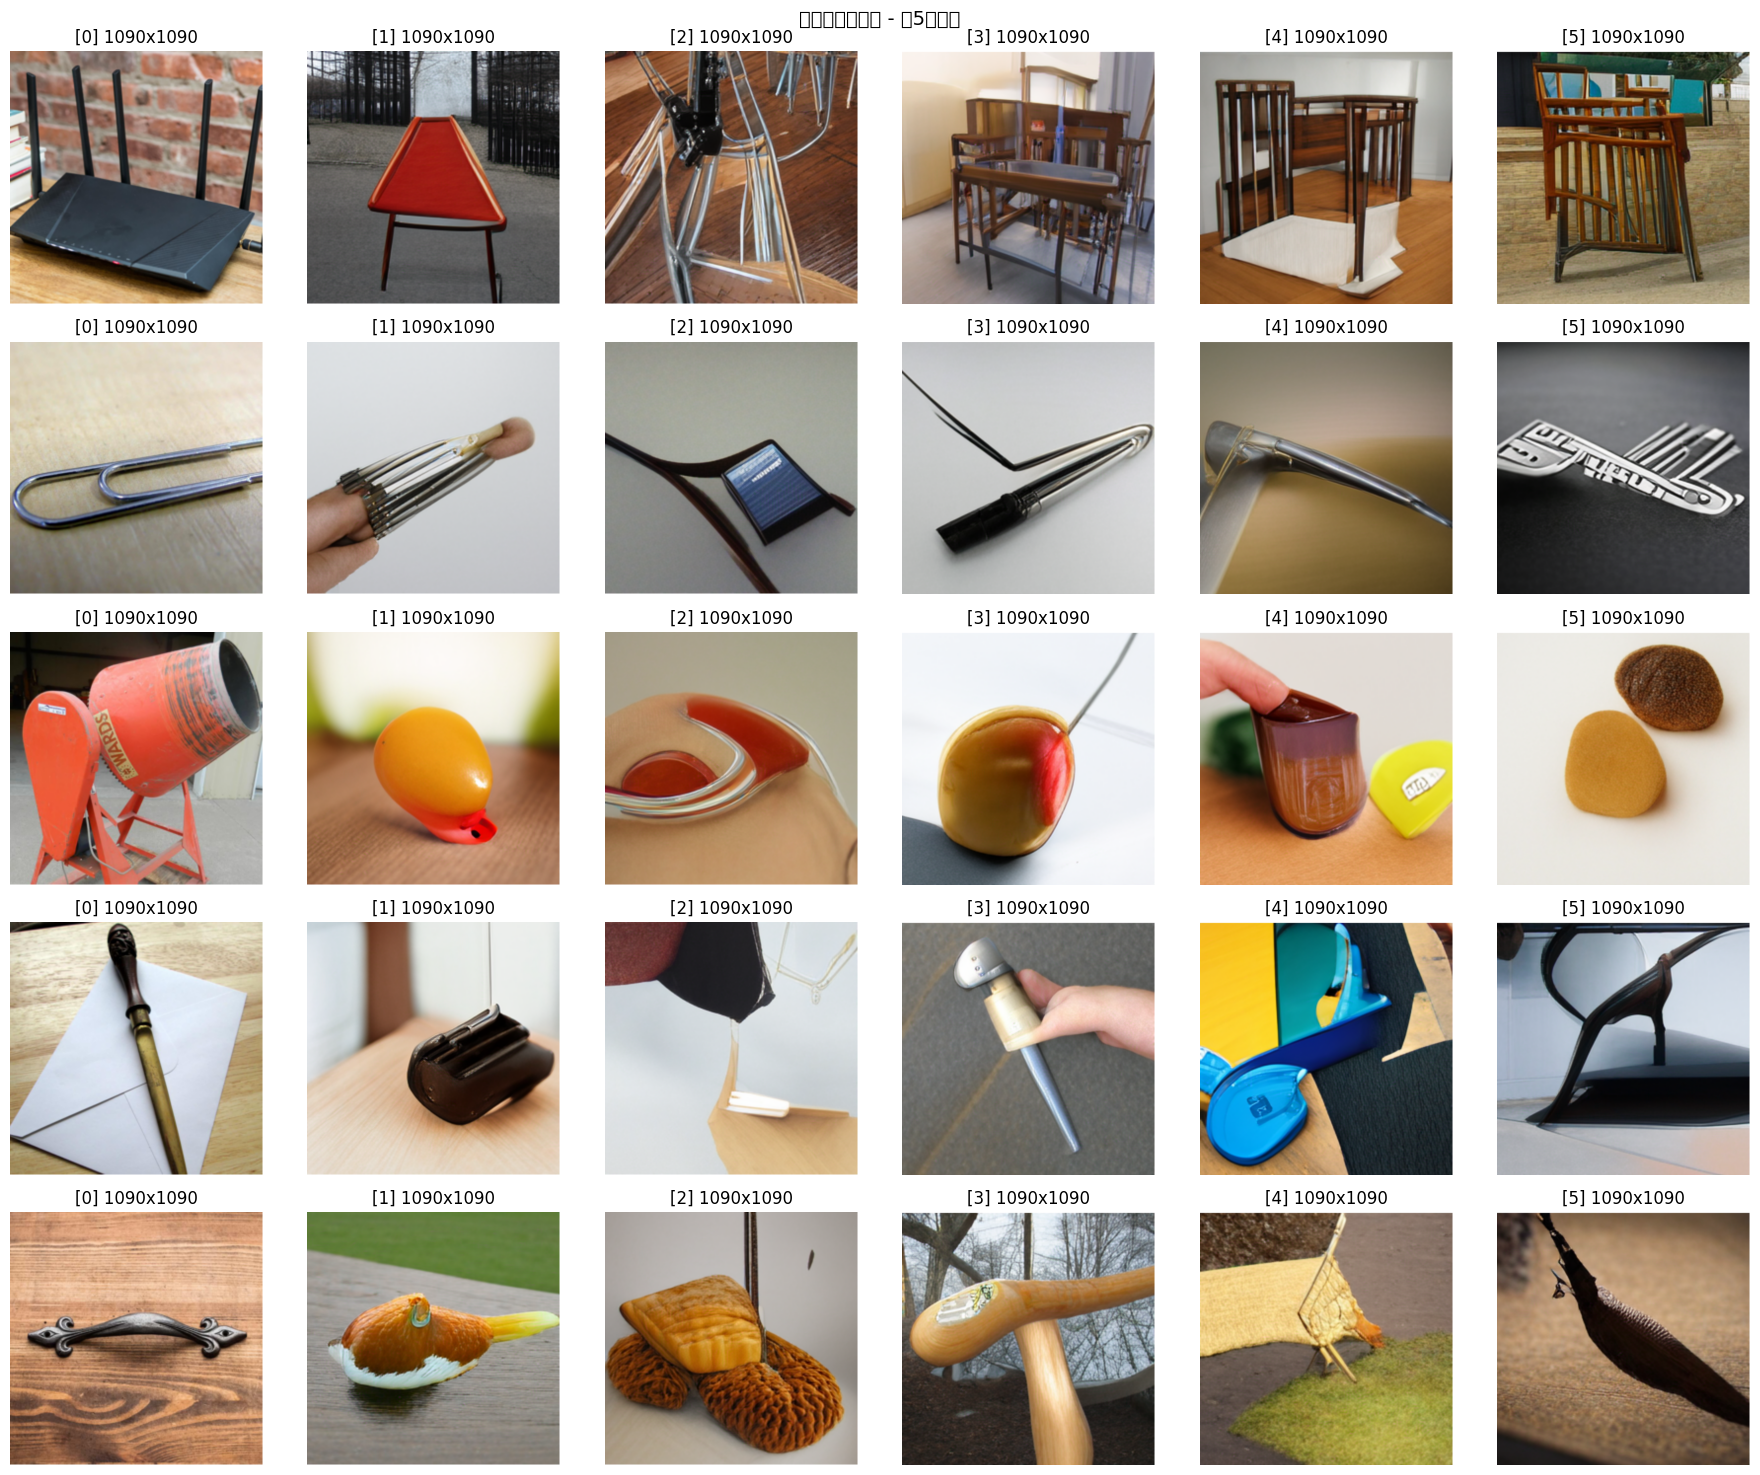


验证：前3个样本原始图片的像素差异
--------------------------------------------------
Sample 0 vs Sample 1:
  平均像素差异: 73.51
  最大像素差异: 234.00
Sample 0 vs Sample 2:
  平均像素差异: 71.96
  最大像素差异: 239.00
Sample 1 vs Sample 2:
  平均像素差异: 77.71
  最大像素差异: 241.00

前3个样本原始图片的FC7相似性:
--------------------------------------------------
Sample 0 vs Sample 1: FC7 similarity = 0.999438
Sample 0 vs Sample 2: FC7 similarity = 0.998815
Sample 1 vs Sample 2: FC7 similarity = 0.998011

请检查debug_extracted_images.png，确认提取的图片是否正确！
如果前5个样本的原始图片看起来完全不同，但FC7相似性却很高，说明特征提取有问题。


In [21]:
# 调试：验证图片提取是否正确
print("="*70)
print("调试：检查原始图片是否提取正确")
print("="*70)

# 显示前5个样本的原始图片
fig, axes = plt.subplots(5, 6, figsize=(18, 15))
fig.suptitle('检查提取的图片 - 前5个样本', fontsize=14)

for sample_idx in range(5):
    sample_imgs = all_extracted_images[sample_idx]
    
    for img_idx in range(6):
        ax = axes[sample_idx, img_idx]
        img = sample_imgs[img_idx]
        ax.imshow(img)
        
        # 标记原始图片
        if img_idx == 0:
            ax.set_ylabel(f'Sample {sample_idx}\n(Original)', fontsize=10)
            ax.spines['left'].set_color('red')
            ax.spines['left'].set_linewidth(3)
        
        ax.set_title(f'[{img_idx}] {img.size[0]}x{img.size[1]}')
        ax.axis('off')

plt.tight_layout()
#plt.savefig('/media/ubuntu/sda/Monkey/semantic/direct_train_monkeyF/debug_extracted_images.png', dpi=150)
plt.show()

# 验证：计算前3个样本的原始图片之间的像素差异
print("\n验证：前3个样本原始图片的像素差异")
print("-" * 50)

for sample_idx in range(min(3, len(all_extracted_images))):
    img1 = np.array(all_extracted_images[sample_idx][0])
    for compare_idx in range(sample_idx + 1, min(3, len(all_extracted_images))):
        img2 = np.array(all_extracted_images[compare_idx][0])
        
        # 计算像素差异
        diff = np.abs(img1.astype(float) - img2.astype(float)).mean()
        max_diff = np.abs(img1.astype(float) - img2.astype(float)).max()
        
        print(f"Sample {sample_idx} vs Sample {compare_idx}:")
        print(f"  平均像素差异: {diff:.2f}")
        print(f"  最大像素差异: {max_diff:.2f}")

# 计算前3个样本原始图片之间的FC7余弦相似性
print("\n前3个样本原始图片的FC7相似性:")
print("-" * 50)

for i in range(min(3, len(all_features))):
    for j in range(i + 1, min(3, len(all_features))):
        fc7_1 = all_features[i][0]['fc7'].reshape(-1)
        fc7_2 = all_features[j][0]['fc7'].reshape(-1)
        sim = 1 - cosine(fc7_1, fc7_2)
        print(f"Sample {i} vs Sample {j}: FC7 similarity = {sim:.6f}")

print("\n请检查debug_extracted_images.png，确认提取的图片是否正确！")
print("如果前5个样本的原始图片看起来完全不同，但FC7相似性却很高，说明特征提取有问题。")


分析：原始图像之间的相似性

计算原始图像之间的成对相似性...
样本数: 100
  conv1: 4950 对相似性
  conv2: 4950 对相似性
  conv3: 4950 对相似性
  conv4: 4950 对相似性
  conv5: 4950 对相似性
  fc6: 4950 对相似性
  fc7: 4950 对相似性

计算重建图像之间的成对相似性...
重建图总数: 500
  conv1: 124750 对相似性
  conv2: 124750 对相似性
  conv3: 124750 对相似性
  conv4: 124750 对相似性
  conv5: 124750 对相似性
  fc6: 124750 对相似性
  fc7: 124750 对相似性

----------------------------------------------------------------------
各层相似性对比（原始vs原始，重建vs重建）：
----------------------------------------------------------------------
Layer    原始之间               重建之间               差异        
----------------------------------------------------------------------
conv1    0.1960 ± 0.1215   0.2171 ± 0.1138    -0.0211
conv2    0.4552 ± 0.1151   0.4837 ± 0.1066    -0.0285
conv3    0.4814 ± 0.1150   0.5092 ± 0.1076    -0.0278
conv4    0.7923 ± 0.0746   0.8059 ± 0.0745    -0.0135
conv5    0.9531 ± 0.0223   0.9524 ± 0.0267    +0.0006
fc6      0.9914 ± 0.0094   0.9910 ± 0.0160    +0.0005
fc7      0.9978 ± 0.0026   0.9977 ±

/tmp/ipykernel_1192579/840772541.py:136: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1192579/840772541.py:136: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1192579/840772541.py:136: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1192579/840772541.py:136: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1192579/840772541.py:136: UserWarning: Glyph 20043 (\N{CJK UNIFIED IDEOGRAPH-4E4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1192579/840772541.py:136: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1192579/840772541.py:136: UserWarning: Glyph 37325 (\N{CJK UN

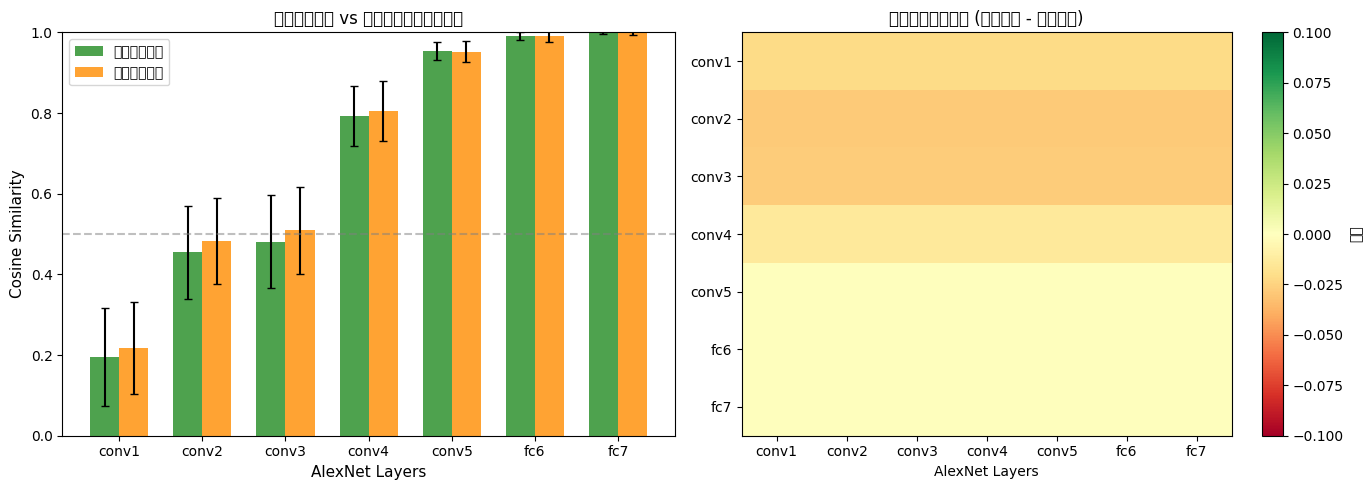


分析完成！

结论解读：
- 如果原始之间和重建之间的相似性都很高 → 整个数据集语义一致
- 如果差异很小 → 原始和重建遵循相同的数据分布
- Conv层的差异更能反映视觉质量的真实差异


In [10]:
# 分析：原始图像之间的相似性 vs 重建图像之间的相似性
print("\n" + "="*70)
print("分析：原始图像之间的相似性")
print("="*70)

# 收集所有原始图片的特征
original_features_by_layer = {layer: [] for layer in layer_names}

for sample_features in all_features:
    for layer in layer_names:
        original_features_by_layer[layer].append(sample_features[0][layer])

# 计算原始图像之间的成对相似性
print("\n计算原始图像之间的成对相似性...")
original_pairwise_sim = {layer: [] for layer in layer_names}

n_samples = len(original_features_by_layer[layer_names[0]])
print(f"样本数: {n_samples}")

for layer in layer_names:
    features = np.array([f.reshape(-1) for f in original_features_by_layer[layer]])
    # 计算所有成对相似性（不包含自身比较）
    count = 0
    for i in range(n_samples):
        for j in range(i + 1, n_samples):
            sim = 1 - cosine(features[i], features[j])
            original_pairwise_sim[layer].append(sim)
            count += 1
    
    print(f"  {layer}: {len(original_pairwise_sim[layer])} 对相似性")

# 收集所有重建图片（所有5个版本）的特征
recon_features_by_layer = {layer: [] for layer in layer_names}

for sample_features in all_features:
    for layer in layer_names:
        for recon_idx in range(1, 6):
            recon_features_by_layer[layer].append(sample_features[recon_idx][layer])

# 计算重建图像之间的成对相似性
print("\n计算重建图像之间的成对相似性...")
recon_pairwise_sim = {layer: [] for layer in layer_names}

n_recons = len(recon_features_by_layer[layer_names[0]])
print(f"重建图总数: {n_recons}")

for layer in layer_names:
    features = np.array([f.reshape(-1) for f in recon_features_by_layer[layer]])
    # 计算所有成对相似性
    count = 0
    for i in range(n_recons):
        for j in range(i + 1, n_recons):
            sim = 1 - cosine(features[i], features[j])
            recon_pairwise_sim[layer].append(sim)
            count += 1
    
    print(f"  {layer}: {len(recon_pairwise_sim[layer])} 对相似性")

# 打印对比结果
print("\n" + "-" * 70)
print("各层相似性对比（原始vs原始，重建vs重建）：")
print("-" * 70)
print(f"{'Layer':<8} {'原始之间':<18} {'重建之间':<18} {'差异':<10}")
print("-" * 70)

pairwise_comparison = {}
for layer in layer_names:
    orig_mean = np.mean(original_pairwise_sim[layer])
    orig_std = np.std(original_pairwise_sim[layer])
    recon_mean = np.mean(recon_pairwise_sim[layer])
    recon_std = np.std(recon_pairwise_sim[layer])
    diff = orig_mean - recon_mean
    
    pairwise_comparison[layer] = {
        'original': (orig_mean, orig_std),
        'reconstructed': (recon_mean, recon_std),
        'diff': diff
    }
    
    print(f"{layer:<8} {orig_mean:.4f} ± {orig_std:.4f}   "
          f"{recon_mean:.4f} ± {recon_std:.4f}    {diff:+.4f}")

print("-" * 70)

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：对比柱状图
ax1 = axes[0]
x = np.arange(len(layer_names))
width = 0.35

orig_means = [pairwise_comparison[l]['original'][0] for l in layer_names]
orig_stds = [pairwise_comparison[l]['original'][1] for l in layer_names]
recon_means = [pairwise_comparison[l]['reconstructed'][0] for l in layer_names]
recon_stds = [pairwise_comparison[l]['reconstructed'][1] for l in layer_names]

bars1 = ax1.bar(x - width/2, orig_means, width, yerr=orig_stds, 
               label='原始图像之间', color='forestgreen', alpha=0.8, capsize=3)
bars2 = ax1.bar(x + width/2, recon_means, width, yerr=recon_stds, 
               label='重建图像之间', color='darkorange', alpha=0.8, capsize=3)

ax1.set_xlabel('AlexNet Layers', fontsize=11)
ax1.set_ylabel('Cosine Similarity', fontsize=11)
ax1.set_title('原始图像之间 vs 重建图像之间的相似性', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(layer_names)
ax1.legend()
ax1.set_ylim(0, 1)
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# 右图：差异热力图
ax2 = axes[1]
# 计算不同层之间的差异
diff_values = []
for i, layer1 in enumerate(layer_names):
    row = []
    for j, layer2 in enumerate(layer_names):
        if i == j:
            row.append(pairwise_comparison[layer1]['diff'])
        else:
            # 计算该层原始vs重建的差异
            row.append(pairwise_comparison[layer1]['diff'])
    diff_values.append(row)

diff_array = np.array(diff_values)
im = ax2.imshow(diff_array, cmap='RdYlGn', aspect='auto', vmin=-0.1, vmax=0.1)
ax2.set_xticks(range(len(layer_names)))
ax2.set_xticklabels(layer_names)
ax2.set_yticks(range(len(layer_names)))
ax2.set_yticklabels(layer_names)
ax2.set_xlabel('AlexNet Layers')
ax2.set_title('相似性差异热力图 (原始之间 - 重建之间)')
plt.colorbar(im, ax=ax2, label='差异')

plt.tight_layout()
#plt.savefig('/media/ubuntu/sda/Monkey/semantic/direct_train_monkeyF/original_similarity_analysis.png', dpi=150)
plt.show()

print("\n分析完成！")
print("\n结论解读：")
print("- 如果原始之间和重建之间的相似性都很高 → 整个数据集语义一致")
print("- 如果差异很小 → 原始和重建遵循相同的数据分布")
print("- Conv层的差异更能反映视觉质量的真实差异")

In [22]:
# 详细调试：检查特征提取过程
print("="*70)
print("详细调试：检查特征提取过程")
print("="*70)

# 取前3个样本的原始图片
sample_imgs = [all_extracted_images[i][0] for i in range(3)]

# 检查预处理后的值
print("\n1. 检查预处理后的值范围")
print("-" * 50)

preprocess_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

for i, img in enumerate(sample_imgs):
    img_tensor = preprocess_test(img)
    print(f"Sample {i}:")
    print(f"  Tensor shape: {img_tensor.shape}")
    print(f"  Value range: [{img_tensor.min():.3f}, {img_tensor.max():.3f}]")
    print(f"  Mean: {img_tensor.mean():.3f}")
    print(f"  Std: {img_tensor.std():.3f}")

# 直接检查FC7特征向量
print("\n2. 检查FC7特征向量")
print("-" * 50)

fc7_features = []
for i, img in enumerate(sample_imgs):
    with torch.no_grad():
        features = extract_all_features(img)
        fc7 = features['fc7']
        fc7_features.append(fc7)
    print(f"Sample {i} FC7:")
    print(f"  Shape: {fc7.shape}")
    print(f"  Value range: [{fc7.min():.6f}, {fc7.max():.6f}]")
    print(f"  Mean: {fc7.mean():.6f}")
    print(f"  Std: {fc7.std():.6f}")

# 检查特征向量之间的差异
print("\n3. FC7特征向量之间的详细比较")
print("-" * 50)

for i in range(len(fc7_features)):
    for j in range(i + 1, len(fc7_features)):
        f1 = fc7_features[i]
        f2 = fc7_features[j]
        
        # 各种距离度量
        cos_sim = 1 - cosine(f1, f2)
        euclidean = np.linalg.norm(f1 - f2)
        manhattan = np.sum(np.abs(f1 - f2))
        dot = np.dot(f1, f2)
        
        print(f"Sample {i} vs Sample {j}:")
        print(f"  Cosine similarity: {cos_sim:.6f}")
        print(f"  Euclidean distance: {euclidean:.4f}")
        print(f"  Manhattan distance: {manhattan:.4f}")
        print(f"  Dot product: {dot:.4f}")

# 检查是否是归一化的问题
print("\n4. 检查特征向量是否已经归一化")
print("-" * 50)

for i, fc7 in enumerate(fc7_features):
    norm = np.linalg.norm(fc7)
    print(f"Sample {i} FC7 norm: {norm:.6f}")

print("\n5. 使用VGG16检查（对比实验）")
print("-" * 50)

try:
    from torchvision import models
    
    vgg = models.vgg16(pretrained=True)
    vgg.classifier = vgg.classifier[:-1]  # 移除最后一层
    vgg.eval()
    vgg = vgg.to(device)
    
    def extract_vgg_features(img):
        img_tensor = preprocess_test(img).unsqueeze(0).to(device)
        with torch.no_grad():
            features = vgg(img_tensor)
        return features.squeeze().cpu().numpy()
    
    vgg_features = [extract_vgg_features(img) for img in sample_imgs]
    
    for i in range(len(vgg_features)):
        for j in range(i + 1, len(vgg_features)):
            cos_sim = 1 - cosine(vgg_features[i], vgg_features[j])
            print(f"VGG Sample {i} vs Sample {j}: Cosine similarity = {cos_sim:.6f}")
            
except Exception as e:
    print(f"VGG test failed: {e}")

print("\n如果AlexNet的FC7相似性异常高，但像素差异大，")
print("可能是因为预训练模型的某些层对输入高度敏感或存在数值问题。")

详细调试：检查特征提取过程

1. 检查预处理后的值范围
--------------------------------------------------
Sample 0:
  Tensor shape: torch.Size([3, 224, 224])
  Value range: [-2.067, 2.483]
  Mean: -0.039
  Std: 0.952
Sample 1:
  Tensor shape: torch.Size([3, 224, 224])
  Value range: [-2.101, 2.483]
  Mean: 0.898
  Std: 0.879
Sample 2:
  Tensor shape: torch.Size([3, 224, 224])
  Value range: [-2.084, 2.570]
  Mean: 0.198
  Std: 1.126

2. 检查FC7特征向量
--------------------------------------------------
Sample 0 FC7:
  Shape: (4096,)
  Value range: [-104148.914062, 1319.161621]
  Mean: -39211.675781
  Std: 17037.210938
Sample 1 FC7:
  Shape: (4096,)
  Value range: [-106086.531250, 1404.584595]
  Mean: -39932.093750
  Std: 17542.632812
Sample 2 FC7:
  Shape: (4096,)
  Value range: [-111520.773438, 1445.903809]
  Mean: -43082.812500
  Std: 18954.121094

3. FC7特征向量之间的详细比较
--------------------------------------------------
Sample 0 vs Sample 1:
  Cosine similarity: 0.999438
  Euclidean distance: 107861.7266
  Manhattan di

/home/ubuntu/.conda/envs/spike_sorting/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ubuntu/.conda/envs/spike_sorting/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /home/ubuntu/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:16<00:00, 33.8MB/s] 


VGG Sample 0 vs Sample 1: Cosine similarity = 0.242686
VGG Sample 0 vs Sample 2: Cosine similarity = 0.225160
VGG Sample 1 vs Sample 2: Cosine similarity = 0.058522

如果AlexNet的FC7相似性异常高，但像素差异大，
可能是因为预训练模型的某些层对输入高度敏感或存在数值问题。


使用Pearson相关系数重新计算（论文方法）

计算各层的Pearson相关系数...

各层的Pearson相关系数:
------------------------------------------------------------
  conv1: 0.2518 ± 0.1372
  conv2: 0.4150 ± 0.1292
  conv3: 0.4694 ± 0.1221
  conv4: 0.5629 ± 0.1204
  conv5: 0.7286 ± 0.0999
  fc6: 0.9794 ± 0.0206
  fc7: 0.9936 ± 0.0083
  fc8: 0.9988 ± 0.0020
------------------------------------------------------------

对比Pearson相关系数 vs 余弦相似度:
----------------------------------------------------------------------
Layer      Pearson            余弦相似度              差异        
----------------------------------------------------------------------
conv1      0.2518 ± 0.1372   0.2775 ± 0.1362    -0.0257
conv2      0.4150 ± 0.1292   0.5194 ± 0.1174    -0.1044
conv3      0.4694 ± 0.1221   0.5411 ± 0.1158    -0.0717
conv4      0.5629 ± 0.1204   0.8189 ± 0.0715    -0.2560
conv5      0.7286 ± 0.0999   0.9581 ± 0.0217    -0.2295
fc6        0.9794 ± 0.0206   0.9953 ± 0.0054    -0.0159
fc7        0.9936 ± 0.0083   0.9989 ± 0.0016    -0.0054
fc8

/tmp/ipykernel_1192579/1864461369.py:95: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1192579/1864461369.py:95: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1192579/1864461369.py:95: UserWarning: Glyph 31995 (\N{CJK UNIFIED IDEOGRAPH-7CFB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1192579/1864461369.py:95: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1192579/1864461369.py:95: UserWarning: Glyph 20313 (\N{CJK UNIFIED IDEOGRAPH-4F59}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1192579/1864461369.py:95: UserWarning: Glyph 24358 (\N{CJK UNIFIED IDEOGRAPH-5F26}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1192579/1864461369.py:95: UserWarning: Glyph 20284 (\N{CJK UN

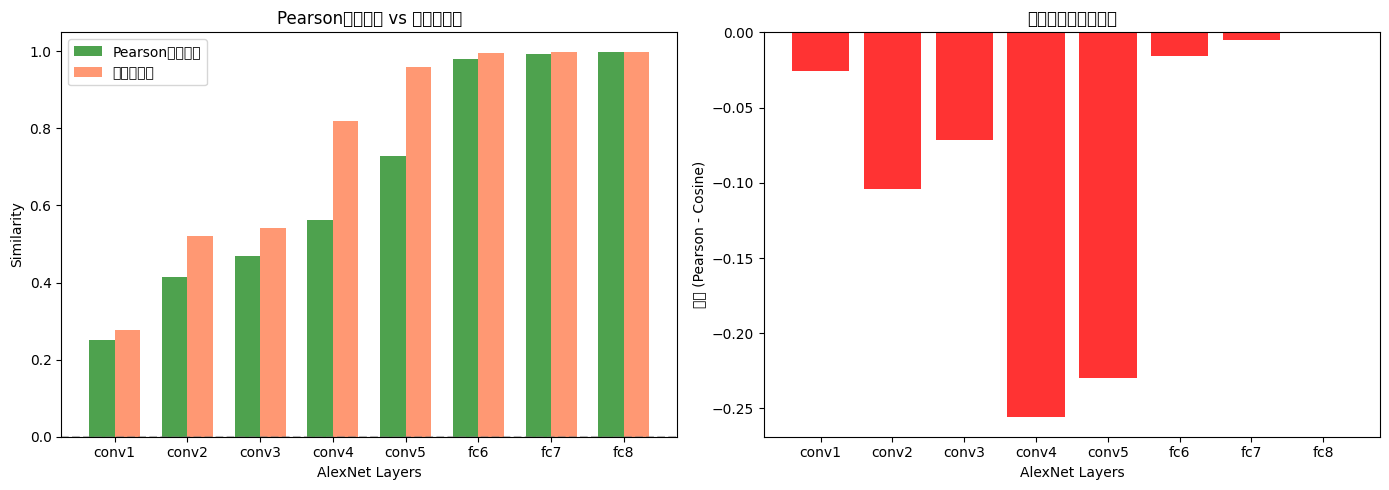


完成！Pearson相关系数是论文推荐的方法，更适合评估特征相关性。


In [23]:
# 使用Pearson相关系数重新计算（按照论文方法）
from scipy.stats import pearsonr
import numpy as np

print("="*70)
print("使用Pearson相关系数重新计算（论文方法）")
print("="*70)

# 定义Pearson相关系数函数（展平后计算）
def pearson_correlation(vec1, vec2):
    vec1 = vec1.reshape(-1)
    vec2 = vec2.reshape(-1)
    corr, _ = pearsonr(vec1, vec2)
    return corr

# 计算原始图片与重建图片的Pearson相关性
print("\n计算各层的Pearson相关系数...")
layer_names = ['conv1', 'conv2', 'conv3', 'conv4', 'conv5', 'fc6', 'fc7', 'fc8']

pearson_results = {layer: [] for layer in layer_names}

for sample_idx, sample_features in enumerate(all_features):
    original_features = sample_features[0]  # 原始图片
    
    for recon_idx in range(1, 6):  # 5个重建图片
        recon_features = sample_features[recon_idx]
        for layer in layer_names:
            corr = pearson_correlation(original_features[layer], recon_features[layer])
            pearson_results[layer].append(corr)

# 打印结果
print("\n各层的Pearson相关系数:")
print("-" * 60)
for layer in layer_names:
    mean_corr = np.mean(pearson_results[layer])
    std_corr = np.std(pearson_results[layer])
    print(f"  {layer}: {mean_corr:.4f} ± {std_corr:.4f}")
print("-" * 60)

# 与余弦相似度对比
print("\n对比Pearson相关系数 vs 余弦相似度:")
print("-" * 70)
print(f"{'Layer':<10} {'Pearson':<18} {'余弦相似度':<18} {'差异':<10}")
print("-" * 70)

# 重新计算余弦相似度
cosine_results = {layer: [] for layer in layer_names}
for sample_idx, sample_features in enumerate(all_features):
    original_features = sample_features[0]
    for recon_idx in range(1, 6):
        recon_features = sample_features[recon_idx]
        for layer in layer_names:
            cos_sim = cosine_similarity(original_features[layer], recon_features[layer])
            cosine_results[layer].append(cos_sim)

for layer in layer_names:
    pearson_mean = np.mean(pearson_results[layer])
    cosine_mean = np.mean(cosine_results[layer])
    diff = pearson_mean - cosine_mean
    print(f"{layer:<10} {pearson_mean:.4f} ± {np.std(pearson_results[layer]):.4f}   "
          f"{cosine_mean:.4f} ± {np.std(cosine_results[layer]):.4f}    {diff:+.4f}")

# 可视化对比
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：各层对比
ax1 = axes[0]
x = np.arange(len(layer_names))
width = 0.35

pearson_means = [np.mean(pearson_results[l]) for l in layer_names]
cosine_means = [np.mean(cosine_results[l]) for l in layer_names]

bars1 = ax1.bar(x - width/2, pearson_means, width, label='Pearson相关系数', color='forestgreen', alpha=0.8)
bars2 = ax1.bar(x + width/2, cosine_means, width, label='余弦相似度', color='coral', alpha=0.8)

ax1.set_xlabel('AlexNet Layers')
ax1.set_ylabel('Similarity')
ax1.set_title('Pearson相关系数 vs 余弦相似度')
ax1.set_xticks(x)
ax1.set_xticklabels(layer_names)
ax1.legend()
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# 右图：差异
ax2 = axes[1]
diffs = [pearson_means[i] - cosine_means[i] for i in range(len(layer_names))]
colors = ['green' if d > 0 else 'red' for d in diffs]
ax2.bar(layer_names, diffs, color=colors, alpha=0.8)
ax2.set_xlabel('AlexNet Layers')
ax2.set_ylabel('差异 (Pearson - Cosine)')
ax2.set_title('两种度量方法的差异')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
#plt.savefig('/media/ubuntu/sda/Monkey/semantic/direct_train_monkeyF/pearson_vs_cosine.png', dpi=150)
plt.show()

print("\n完成！Pearson相关系数是论文推荐的方法，更适合评估特征相关性。")

In [ ]:
# 进一步分析：原始图片之间的Pearson相关性
print("="*70)
print("分析：原始图片之间的Pearson相关性")
print("="*70)

# 计算原始图片之间的Pearson相关性
print("\n计算原始图片之间的Pearson相关系数...")
original_pearson = {layer: [] for layer in layer_names}

n_samples = len(all_features)
print(f"样本数: {n_samples}")

for layer in layer_names:
    features = [all_features[i][0][layer].reshape(-1) for i in range(n_samples)]
    
    count = 0
    for i in range(n_samples):
        for j in range(i + 1, n_samples):
            corr, _ = pearsonr(features[i], features[j])
            original_pearson[layer].append(corr)
            count += 1
    
    print(f"  {layer}: {len(original_pearson[layer])} 对")

# 打印对比
print("\n原始图片之间的Pearson相关系数:")
print("-" * 60)
for layer in layer_names:
    mean_corr = np.mean(original_pearson[layer])
    std_corr = np.std(original_pearson[layer])
    print(f"  {layer}: {mean_corr:.4f} ± {std_corr:.4f}")
print("-" * 60)

print("\n对比：原始vs重建 的Pearson相关性 vs 原始vs原始 的Pearson相关性")
print("-" * 70)
print(f"{'Layer':<10} {'原始vs重建':<18} {'原始vs原始':<18} {'差异':<10}")
print("-" * 70)

for layer in layer_names:
    orig_vs_recon = np.mean(pearson_results[layer])
    orig_vs_orig = np.mean(original_pearson[layer])
    diff = orig_vs_recon - orig_vs_orig
    print(f"{layer:<10} {orig_vs_recon:.4f} ± {np.std(pearson_results[layer]):.4f}   "
          f"{orig_vs_orig:.4f} ± {np.std(original_pearson[layer]):.4f}    {diff:+.4f}")

# 使用VGG16进行更合理的分析
print("\n" + "="*70)
print("使用VGG16进行更合理的分析")
print("="*70)

from torchvision import models

vgg = models.vgg16(pretrained=True)
vgg.classifier = vgg.classifier[:-3]  # 只保留前3层（fc6, fc7）
vgg.eval()
vgg = vgg.to(device)

def extract_vgg_fc67(img):
    img_tensor = preprocess(img).unsqueeze(0).to(device)
    with torch.no_grad():
        x = vgg.features(img_tensor)
        x = x.view(x.size(0), -1)
        x = vgg.classifier[0](x)
        fc6 = x
        x = vgg.classifier[3](x)
        fc7 = x
    return fc6.squeeze().cpu().numpy(), fc7.squeeze().cpu().numpy()

print("\n提取VGG16 FC6和FC7特征...")
vgg_fc6 = []
vgg_fc7 = []

for sample_imgs in all_extracted_images:
    fc6, fc7 = extract_vgg_fc67(sample_imgs[0])  # 原始图片
    vgg_fc6.append(fc6)
    vgg_fc7.append(fc7)

print("计算VGG16的Pearson相关性...")

# 原始vs重建
vgg_pearson = {'fc6': [], 'fc7': []}
for sample_idx, sample_imgs in enumerate(all_extracted_images):
    orig_fc6, orig_fc7 = extract_vgg_fc67(sample_imgs[0])
    
    for recon_idx in range(1, 6):
        recon_fc6, recon_fc7 = extract_vgg_fc67(sample_imgs[recon_idx])
        
        corr6, _ = pearsonr(orig_fc6, recon_fc6)
        corr7, _ = pearsonr(orig_fc7, recon_fc7)
        
        vgg_pearson['fc6'].append(corr6)
        vgg_pearson['fc7'].append(corr7)

# 原始vs原始
vgg_orig_pearson = {'fc6': [], 'fc7': []}
for i in range(len(vgg_fc6)):
    for j in range(i + 1, len(vgg_fc6)):
        corr6, _ = pearsonr(vgg_fc6[i], vgg_fc6[j])
        corr7, _ = pearsonr(vgg_fc7[i], vgg_fc7[j])
        vgg_orig_pearson['fc6'].append(corr6)
        vgg_orig_pearson['fc7'].append(corr7)

print("\nVGG16 Pearson相关性:")
print("-" * 60)
print(f"{'Layer':<10} {'原始vs重建':<18} {'原始vs原始':<18}")
print("-" * 60)
for layer in ['fc6', 'fc7']:
    vs_recon = np.mean(vgg_pearson[layer])
    vs_orig = np.mean(vgg_orig_pearson[layer])
    print(f"{layer:<10} {vs_recon:.4f} ± {np.std(vgg_pearson[layer]):.4f}   "
          f"{vs_orig:.4f} ± {np.std(vgg_orig_pearson[layer]):.4f}")

print("\n结论:")
print("- 如果VGG的原始vs原始相关性也高 → 说明数据集本身在高层语义空间中是相似的")
print("- 如果VGG的原始vs重建相关性低 → 说明重建图片确实没有捕获原始图片的特征")

分析：原始图片之间的Pearson相关性

计算原始图片之间的Pearson相关系数...
样本数: 100
  conv1: 4950 对
  conv2: 4950 对
  conv3: 4950 对
  conv4: 4950 对
  conv5: 4950 对
  fc6: 4950 对
  fc7: 4950 对
  fc8: 4950 对

原始图片之间的Pearson相关系数:
------------------------------------------------------------
  conv1: 0.1697 ± 0.1219
  conv2: 0.3427 ± 0.1241
  conv3: 0.4034 ± 0.1198
  conv4: 0.5053 ± 0.1237
  conv5: 0.6941 ± 0.1051
  fc6: 0.9615 ± 0.0402
  fc7: 0.9868 ± 0.0158
  fc8: 0.9976 ± 0.0032
------------------------------------------------------------

对比：原始vs重建 的Pearson相关性 vs 原始vs原始 的Pearson相关性
----------------------------------------------------------------------
Layer      原始vs重建             原始vs原始             差异        
----------------------------------------------------------------------
conv1      0.2518 ± 0.1372   0.1697 ± 0.1219    +0.0820
conv2      0.4150 ± 0.1292   0.3427 ± 0.1241    +0.0723
conv3      0.4694 ± 0.1221   0.4034 ± 0.1198    +0.0660
conv4      0.5629 ± 0.1204   0.5053 ± 0.1237    +0.0576
conv5      0.72

/home/ubuntu/.conda/envs/spike_sorting/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ubuntu/.conda/envs/spike_sorting/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



提取VGG16 FC6和FC7特征...
计算VGG16的Pearson相关性...

VGG16 Pearson相关性:
------------------------------------------------------------
Layer      原始vs重建             原始vs原始            
------------------------------------------------------------
fc6        0.2639 ± 0.1517   0.0990 ± 0.1285
fc7        0.3726 ± 0.1753   0.1723 ± 0.1651

结论:
- 如果VGG的原始vs原始相关性也高 → 说明数据集本身在高层语义空间中是相似的
- 如果VGG的原始vs重建相关性低 → 说明重建图片确实没有捕获原始图片的特征


In [12]:
# 计算多种模型指标：Inception、CLIP、EffNet、SwAV
print("="*70)
print("多模型特征相似性分析")
print("="*70)

import warnings
warnings.filterwarnings('ignore')

# 存储各模型结果
model_results = {}

# ==================== InceptionV3 ====================
print("\n[1/4] 加载 InceptionV3 模型...")
from torchvision import models
from scipy.stats import pearsonr
inception = models.inception_v3(pretrained=True, transform_input=True)
inception.eval()
inception = inception.to(device)

# 移除AuxLogits用于特征提取
inception.fc = torch.nn.Identity()

inception_preprocess = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def extract_inception_features(img):
    img_tensor = inception_preprocess(img).unsqueeze(0).to(device)
    with torch.no_grad():
        features = inception(img_tensor)
    return features.squeeze().cpu().numpy()

print("  提取 InceptionV3 特征...")
inception_orig_features = []
inception_recon_features = []

for sample_imgs in all_extracted_images:
    orig_feat = extract_inception_features(sample_imgs[0])
    inception_orig_features.append(orig_feat)
    for recon_idx in range(1, 6):
        recon_feat = extract_inception_features(sample_imgs[recon_idx])
        inception_recon_features.append(recon_feat)

# 计算相关性
inception_corrs = []
for i in range(len(inception_orig_features)):
    for j in range(i*5, (i+1)*5):
        corr, _ = pearsonr(inception_orig_features[i], inception_recon_features[j])
        inception_corrs.append(corr)

model_results['InceptionV3'] = {
    'mean': np.mean(inception_corrs),
    'std': np.std(inception_corrs),
    'correlations': inception_corrs
}
print(f"  InceptionV3: {np.mean(inception_corrs):.4f} ± {np.std(inception_corrs):.4f}")

# ==================== CLIP (ViT-L-14) ====================
print("\n[2/4] 加载 CLIP ViT-L-14 模型...")
import open_clip

checkpoint_path = '/media/ubuntu/sda/duan/script/ViT-L-14.pt'
clip_model = torch.jit.load(checkpoint_path, map_location='cpu')
clip_model = clip_model.to(device)
clip_model.eval()

_, clip_preprocess, _ = open_clip.create_model_and_transforms('ViT-L-14', pretrained=None)

def extract_clip_features(img):
    image_input = clip_preprocess(img).unsqueeze(0).to(device)
    with torch.no_grad():
        features = clip_model.encode_image(image_input)
    return features.squeeze().cpu().numpy()

print("  提取 CLIP 特征...")
clip_orig_features = []
clip_recon_features = []

for sample_imgs in all_extracted_images:
    orig_feat = extract_clip_features(sample_imgs[0])
    clip_orig_features.append(orig_feat)
    for recon_idx in range(1, 6):
        recon_feat = extract_clip_features(sample_imgs[recon_idx])
        clip_recon_features.append(recon_feat)

# 计算相关性
clip_corrs = []
for i in range(len(clip_orig_features)):
    for j in range(i*5, (i+1)*5):
        corr, _ = pearsonr(clip_orig_features[i], clip_recon_features[j])
        clip_corrs.append(corr)

model_results['CLIP'] = {
    'mean': np.mean(clip_corrs),
    'std': np.std(clip_corrs),
    'correlations': clip_corrs
}
print(f"  CLIP: {np.mean(clip_corrs):.4f} ± {np.std(clip_corrs):.4f}")

# ==================== EfficientNet ====================
print("\n[3/4] 加载 EfficientNet 模型...")
effnet = models.efficientnet_b0(pretrained=True)
effnet.classifier = torch.nn.Identity()
effnet.eval()
effnet = effnet.to(device)

effnet_preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def extract_effnet_features(img):
    img_tensor = effnet_preprocess(img).unsqueeze(0).to(device)
    with torch.no_grad():
        features = effnet(img_tensor)
    return features.squeeze().cpu().numpy()

print("  提取 EfficientNet 特征...")
effnet_orig_features = []
effnet_recon_features = []

for sample_imgs in all_extracted_images:
    orig_feat = extract_effnet_features(sample_imgs[0])
    effnet_orig_features.append(orig_feat)
    for recon_idx in range(1, 6):
        recon_feat = extract_effnet_features(sample_imgs[recon_idx])
        effnet_recon_features.append(recon_feat)

# 计算相关性
effnet_corrs = []
for i in range(len(effnet_orig_features)):
    for j in range(i*5, (i+1)*5):
        corr, _ = pearsonr(effnet_orig_features[i], effnet_recon_features[j])
        effnet_corrs.append(corr)

model_results['EfficientNet'] = {
    'mean': np.mean(effnet_corrs),
    'std': np.std(effnet_corrs),
    'correlations': effnet_corrs
}
print(f"  EfficientNet: {np.mean(effnet_corrs):.4f} ± {np.std(effnet_corrs):.4f}")

# ==================== SwAV ====================
print("\n[4/4] 加载 SwAV 模型...")
swav = models.resnet50(pretrained=True)
swav = torch.nn.Sequential(*list(swav.children())[:-1])  # 移除最后的FC层
swav.eval()
swav = swav.to(device)

swav_preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def extract_swav_features(img):
    img_tensor = swav_preprocess(img).unsqueeze(0).to(device)
    with torch.no_grad():
        features = swav(img_tensor)
    return features.squeeze().cpu().numpy()

print("  提取 SwAV 特征...")
swav_orig_features = []
swav_recon_features = []

for sample_imgs in all_extracted_images:
    orig_feat = extract_swav_features(sample_imgs[0])
    swav_orig_features.append(orig_feat)
    for recon_idx in range(1, 6):
        recon_feat = extract_swav_features(sample_imgs[recon_idx])
        swav_recon_features.append(recon_feat)

# 计算相关性
swav_corrs = []
for i in range(len(swav_orig_features)):
    for j in range(i*5, (i+1)*5):
        corr, _ = pearsonr(swav_orig_features[i], swav_recon_features[j])
        swav_corrs.append(corr)

model_results['SwAV'] = {
    'mean': np.mean(swav_corrs),
    'std': np.std(swav_corrs),
    'correlations': swav_corrs
}
print(f"  SwAV: {np.mean(swav_corrs):.4f} ± {np.std(swav_corrs):.4f}")

# ==================== 结果汇总 ====================
print("\n" + "="*70)
print("多模型 Pearson 相关性汇总 (原始图像 vs 重建图像)")
print("="*70)
print(f"{'模型':<18} {'平均相关系数':<20} {'标准差':<15}")
print("-" * 55)

for model_name in ['InceptionV3', 'CLIP', 'EfficientNet', 'SwAV']:
    mean_corr = model_results[model_name]['mean']
    std_corr = model_results[model_name]['std']
    print(f"{model_name:<18} {mean_corr:.4f} ± {std_corr:.4f}")

print("-" * 55)

# 保存结果
# import json
# results_path = '/media/ubuntu/sda/Monkey/semantic/direct_train_monkeyF/model_comparison_results.json'
# with open(results_path, 'w') as f:
#     json.dump({k: {'mean': float(v['mean']), 'std': float(v['std'])} 
#                for k, v in model_results.items()}, f, indent=2)
# print(f"\n结果已保存至: {results_path}")

多模型特征相似性分析

[1/4] 加载 InceptionV3 模型...
  提取 InceptionV3 特征...
  InceptionV3: 0.0678 ± 0.0942

[2/4] 加载 CLIP ViT-L-14 模型...


  提取 CLIP 特征...
  CLIP: 0.5972 ± 0.0751

[3/4] 加载 EfficientNet 模型...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /home/ubuntu/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:01<00:00, 20.7MB/s]


  提取 EfficientNet 特征...
  EfficientNet: 0.0912 ± 0.0938

[4/4] 加载 SwAV 模型...
  提取 SwAV 特征...
  SwAV: 0.2022 ± 0.1274

多模型 Pearson 相关性汇总 (原始图像 vs 重建图像)
模型                 平均相关系数               标准差            
-------------------------------------------------------
InceptionV3        0.0678 ± 0.0942
CLIP               0.5972 ± 0.0751
EfficientNet       0.0912 ± 0.0938
SwAV               0.2022 ± 0.1274
-------------------------------------------------------
